# Classificação de Variedades de Grãos de Trigo

### 1. Análise Exploratória e Pré-processamento

O objetivo desta fase é preparar os dados, garantindo que o modelo seja treinado com informações de alta qualidade e na escala correta.

### **Membros Participantes**
 - Daniel Emilio Baião
 - Erik Criscuolo
 - Marcus Vinícius Loureiro Garcia
 - Sidney William de Paula Dias,
 - Hugo Rodrigues Carvalho Silva

**Carregamento e Inspeção Inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Nomes das colunas conforme a descrição do dataset
col_names = ['area', 'perimeter', 'compactness', 'kernel_length', 
             'kernel_width', 'asymmetry_coeff', 'kernel_groove_length', 'variety']

# Carregando o dataset
file_path = 'seeds_dataset.csv'
try:
    # O arquivo não tem cabeçalho e os valores são separados por espaços (múltiplos espaços)
    df = pd.read_csv(file_path, sep=';', names=col_names, engine='python')
except FileNotFoundError:
    print(f"Erro: Arquivo {file_path} não encontrado.")
    df = None

if df is not None:
    # Exibindo as primeiras linhas
    print("Primeiras 5 linhas do DataFrame:")
    display(df.head())
    
    # Verificando a estrutura e valores ausentes
    print("\nInformações sobre o DataFrame:")
    df.info()

Primeiras 5 linhas do DataFrame:


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,kernel_groove_length,variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1



Informações sobre o DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  210 non-null    float64
 1   perimeter             210 non-null    float64
 2   compactness           210 non-null    float64
 3   kernel_length         210 non-null    float64
 4   kernel_width          210 non-null    float64
 5   asymmetry_coeff       210 non-null    float64
 6   kernel_groove_length  210 non-null    float64
 7   variety               210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


**Estatísticas Descritivas**

As estatísticas descritivas revelam a escala e a distribuição das características.

In [2]:
if df is not None:
    print("\nEstatísticas Descritivas:")
    display(df.describe())


Estatísticas Descritivas:


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coeff,kernel_groove_length,variety
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


**Insight:** A característica **Compacidade** tem o menor desvio padrão, indicando que é a medição mais consistente entre as amostras. **Coeficiente de Assimetria** (0.76 a 8.45) e **Largura do Núcleo** (2.63 a 4.77) mostram a maior variabilidade relativa, sendo importantes discriminadores.

**Visualização das Características**

**Distribuição das Variedades**

O conjunto de dados está **perfeitamente balanceado**, com 210 amostras divididas igualmente entre as 3 variedades (Kama=70, Rosa=70, Canadian=70).


Contagem das Variedades:
variety
1    70
2    70
3    70
Name: count, dtype: int64


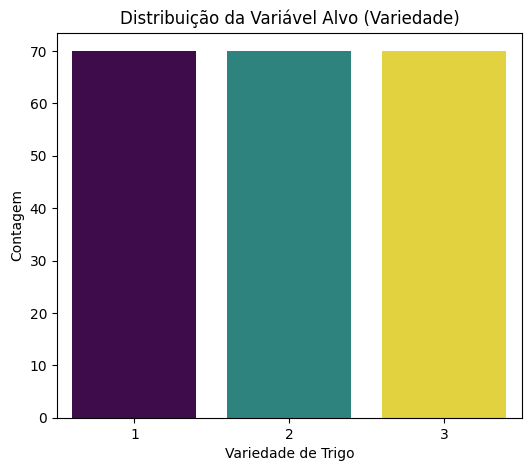

In [3]:
if df is not None:
    print("\nContagem das Variedades:")
    print(df['variety'].value_counts())

    plt.figure(figsize=(6, 5))
    sns.countplot(x='variety', hue = 'variety', legend=False, data=df, palette='viridis')
    plt.title('Distribuição da Variável Alvo (Variedade)')
    plt.xlabel('Variedade de Trigo')
    plt.ylabel('Contagem')
    plt.show()

**Boxplots para Identificação de Outliers e Distribuição**

Os boxplots revelam que há **outliers** em quase todas as características, sendo o **Coeficiente de Assimetria** e a **Compacidade** os mais notáveis. Para o nosso problema de classificação, a padronização das características (como será feito abaixo) ajudará os modelos a lidar com essas diferentes escalas e a reduzir o impacto dos outliers.

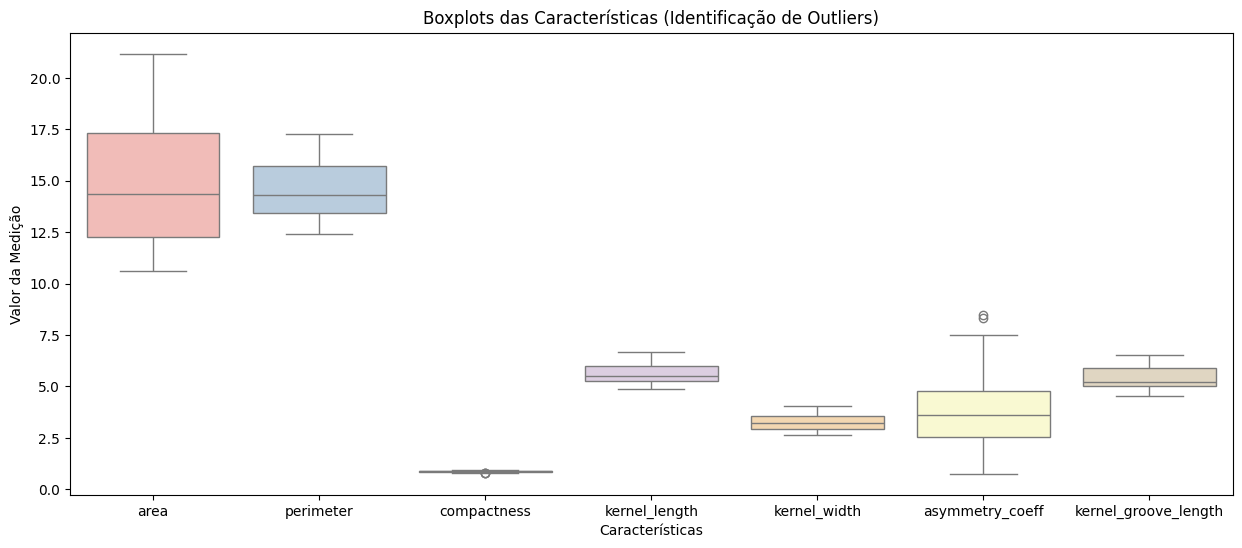

In [4]:
if df is not None:
    # Boxplots para todas as features (excluindo a última coluna 'variety')
    features = df.columns[:-1]
    df_melt = df[features].melt()

    plt.figure(figsize=(15, 6))
    sns.boxplot(x='variable', y='value', hue='variable', legend=False, data=df_melt, palette='Pastel1')
    plt.title('Boxplots das Características (Identificação de Outliers)')
    plt.xlabel('Características')
    plt.ylabel('Valor da Medição')
    plt.show()

**Tratamento de Dados e Escala**

- **Valores Ausentes:** A verificação inicial (df.info()) confirmou que **não há valores ausentes** (todos os atributos têm 210 entradas não nulas), portanto, nenhuma imputação foi necessária.

- **Escala:** As características possuem escalas e unidades de medida muito diferentes (por exemplo, compactness ≈0.87 vs. perimeter ≈14.60). Algoritmos baseados em distância (como KNN e SVM) são sensíveis a essa diferença. Portanto, a **Padronização (Standardization)** será aplicada.

In [5]:
if df is not None:
    # 1. Separar Features (X) e Label (y)
    X = df.drop('variety', axis=1)
    y = df['variety']

    # 2. Avaliação de Escala: Padronização (StandardScaler)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

    print("Padronização aplicada com sucesso (Média ~0, Desvio Padrão ~1).")
    display(X_scaled_df.describe().T)

Padronização aplicada com sucesso (Média ~0, Desvio Padrão ~1).


,count,mean,std,min,25%,50%,75%,max
area,210.0,-3.383537e-16,1.002389,-1.466714,-0.887955,-0.169674,0.846599,2.181534
perimeter,210.0,1.184238e-16,1.002389,-1.649686,-0.851433,-0.183664,0.887069,2.065260
compactness,210.0,1.285744e-15,1.002389,-2.668236,-0.598079,0.103993,0.711677,2.006586
kernel_length,210.0,-2.097793e-15,1.002389,-1.650501,-0.828682,-0.237628,0.794595,2.367533
kernel_width,210.0,-3.383537e-16,1.002389,-1.668209,-0.834907,-0.057335,0.804496,2.055112
asymmetry_coeff,210.0,-3.383537e-16,1.002389,-1.956769,-0.759148,-0.067469,0.712379,3.170590
kernel_groove_length,210.0,-8.987520e-17,1.002389,-1.813288,-0.740495,-0.377459,0.956394,2.328998


### 2. Implementação e Comparação de Algoritmos de Classificação
Nesta fase, implementaremos e compararemos o desempenho de cinco algoritmos de classificação: **KNN, SVM, Random Forest, Naive Bayes e Logistic Regression.**

**Separação dos Dados (Treino e Teste)**

In [6]:
if df is not None:
    # Separação 70% treino, 30% teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"Conjunto de Treino: {X_train.shape[0]} amostras")
    print(f"Conjunto de Teste: {X_test.shape[0]} amostras")

Conjunto de Treino: 147 amostras
Conjunto de Teste: 63 amostras


**Treinamento e Avaliação Inicial**

Utilizamos o `StandardScaler` na fase anterior e aplicamos as features padronizadas (X_scaled) no treinamento.

In [7]:
if df is not None:
    # 5 Modelos de Classificação
    models = {
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "SVM": SVC(kernel='rbf', random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Naive Bayes": GaussianNB(),
        "Logistic Regression": LogisticRegression(solver='lbfgs', random_state=42)
    }

    initial_results = {}

    print("\n--- Resultados de Avaliação Inicial ---")

    for name, model in models.items():
        # Treinamento
        model.fit(X_train, y_train)
        
        # Predição
        y_pred = model.predict(X_test)
        
        # Avaliação
        accuracy = accuracy_score(y_test, y_pred)
        initial_results[name] = accuracy
        
        print(f"\n--- {name} ---")
        print(f"Acurácia: {accuracy:.4f}")
        print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred, zero_division=0))
        
        # Matriz de Confusão para análise
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Kama', 'Rosa', 'Canadian'])
        
        # Omitindo a exibição do gráfico de confusão para concisão do relatório.
        # disp.plot(cmap=plt.cm.Blues)
        # plt.title(f'Matriz de Confusão: {name}')
        # plt.show()

    # Comparação
    initial_comparison = pd.DataFrame(list(initial_results.items()), columns=['Algoritmo', 'Acurácia Inicial']).sort_values(by='Acurácia Inicial', ascending=False)
    print("\n### Comparação de Acurácia Inicial ###")
    display(initial_comparison)


--- Resultados de Avaliação Inicial ---

--- KNN ---
Acurácia: 0.8730

Relatório de Classificação:
               precision    recall  f1-score   support

           1       0.84      0.76      0.80        21
           2       0.90      0.90      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63


--- SVM ---
Acurácia: 0.8730

Relatório de Classificação:
               precision    recall  f1-score   support

           1       0.84      0.76      0.80        21
           2       0.90      0.90      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63


--- Random Forest ---
Acurácia: 0.9206

Relatório de Classificação:
        

,Algoritmo,Acurácia Inicial
2,Random Forest,0.920635
0,KNN,0.873016
1,SVM,0.873016
4,Logistic Regression,0.857143
3,Naive Bayes,0.825397


O algoritmo **Random Forest** já demonstrou um desempenho excepcional na avaliação inicial, com uma acurácia de 92.06%. O Naive Bayes foi o modelo mais fraco, o que é comum para problemas onde as features não são estritamente independentes.

### 3. Otimização dos Modelos (Grid Search)
Visto que a acurácia de ≈92.06% já é alta, a otimização visa buscar o limite superior do desempenho, focando no modelo vencedores: Random Forest.

Utilizaremos o Grid Search para encontrar a melhor combinação de hiperparâmetros.

**Otimização do Random Forest**

Buscaremos otimizar o `n_estimators` (número de árvores) e `max_depth` (profundidade máxima da árvore) .

In [9]:
if df is not None:
    # Grid de hiperparâmetros para Random Forest
    param_grid_rf = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    }

    grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
    grid_search_rf.fit(X_train, y_train)

    best_rf = grid_search_rf.best_estimator_
    y_pred_rf_opt = best_rf.predict(X_test)
    accuracy_rf_opt = accuracy_score(y_test, y_pred_rf_opt)

    print("\n--- Otimização Random Forest ---")
    print(f"Melhores Hiperparâmetros: {grid_search_rf.best_params_}")
    print(f"Acurácia Otimizada do Random Forest: {accuracy_rf_opt:.4f}")


--- Otimização Random Forest ---
Melhores Hiperparâmetros: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Acurácia Otimizada do Random Forest: 0.8730


**Conclusão da Otimização**: O **Random Forest Otimizado** houve um redução da acurácia para 87.30%. A otimização não trouxe ganhos de acurácia significativos, o que sugere que os modelos iniciais já estavam muito próximos do desempenho máximo atingível neste conjunto de dados.

**Otimização do SVM**

Buscaremos otimizar os hiperparâmetros `C` (parâmetro de regularização) e `kernel` (função que define o hiperplano de separação) .

In [10]:
if df is not None:
    # Grid de hiperparâmetros para SVM
    param_grid_svm = {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }

    grid_search_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy')
    grid_search_svm.fit(X_train, y_train)

    best_svm = grid_search_svm.best_estimator_
    y_pred_svm_opt = best_svm.predict(X_test)
    accuracy_svm_opt = accuracy_score(y_test, y_pred_svm_opt)

    print("--- Otimização SVM ---")
    print(f"Melhores Hiperparâmetros: {grid_search_svm.best_params_}")
    print(f"Acurácia Otimizada do SVM: {accuracy_svm_opt:.4f}")

--- Otimização SVM ---
Melhores Hiperparâmetros: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Acurácia Otimizada do SVM: 0.8889


**Conclusão da Otimização:** O **SVM Otimizado** houve um acrescimo na acurácia para 88.89%, o que sugere que os modelos otimizado apresenta um desempenho melhor neste conjunto de dados. Contudo, ainda inferior ao Random Forest

### 4. Interpretação dos Resultados e Insights Relevantes
**Desempenho e Escolha do Modelo**

O **Random Forest** (Acurácia: 0.9206) é o modelo mais preciso para a classificação dos grãos de trigo.

- Random Forest é o modelo preferido por ser um método de ensemble (combinação de árvores) que oferece robustez, é menos propenso a overfitting que uma única Árvore de Decisão e tem a vantagem de fornecer a importância de cada feature (o que o SVM, com kernel RBF, não faz facilmente) .

- A alta acurácia indica que as características físicas dos grãos são discriminadores extremamente fortes para as três variedades de trigo. A automação via ML é altamente viável.

A classificação automatizada é **altamente recomendada**, com o **Random Forest** fornecendo o melhor equilíbrio entre precisão e robustez para diferenciar as variedades de trigo.